
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border:solid green 2px; padding: 20px; border-radius: 10px">
<b>Reviewer's comment v2</b>
    
<b>Overall Feedback</b>

Hello <b>TB-5698</b>!

My name is <b>Carlos Huapaya</b> and I will be your reviewer in this iteration.

You can find me on the HUB as https://hub.tripleten.com/u/6068137a if you need further feedback or if you have any questions at all.

Thank you for submitting your updated project! 🙌 I can see you've addressed the previous feedback and put in solid effort to improve your analysis.
    
---

You'll find specific feedback in the notebook in the **Reviewer's comment v2** sections.
    
**✅ What's Working Well**
- Excellent data preparation process with clear documentation of your decisions
- Strong temporal and platform analysis with thoughtful selection of the 2012-2016 timeframe
- Comprehensive regional analysis showing clear understanding of market differences
- Well-executed hypothesis testing with proper statistical methodology
- Clear, actionable conclusions that tie directly to your analytical findings

**🚧 Suggested Tweaks & Areas for Attention**
- Consider adding a brief written conclusion about ESRB rating impact in regional analysis
- Could benefit from slightly more detailed interpretation of the correlation findings
    
Your analysis demonstrates strong analytical thinking and produces valuable insights for business decision-making. The progression from data preparation through regional analysis to hypothesis testing is well-structured, and your final recommendations are well-supported by the evidence. **This project is approved, congratulations!**
    
---

  <p style="margin-top: 12px"><b>How to read my comments</b></p>

  <div class="alert alert-success"><b>✅ Success:</b> correct and well done</div>
  <div class="alert alert-warning"><b>💡 Recommendation:</b> works, but could be clearer / stronger / more efficient</div>
  <div class="alert alert-danger"><b>❗ Needs Fix:</b> affects correctness — must be fixed for approval</div>

  <p style="margin-top: 10px">
  <b>Please don't move, edit, or delete my comments.</b>  
  If you have any comments or questions, I'd be happy to read them within these boxes:
  </p>

  <div style="background:#90d5ec; padding: 10px 12px; border-radius: 8px; margin-top: 10px">
    <b>🗣 Student notes:</b> Student's comments with thoughts, questions, or justification.
  </div>
</div>

# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
df = pd.read_csv('/datasets/games.csv')

In [3]:
# Display basic information about the dataset
print(df.shape)
print()
print(df.info())
print()
print(df.head())
print()
print(df.describe())

(16715, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      P

In [4]:
# Check for duplicate entries
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### Key Questions to Answer:
- What's the total number of records in our dataset?  16,715 total records
- What data types are present in each column? na_sales, eu_sales, jp_sales, other_sales 
- Are there any obvious issues with the data? Names are uppercase. 
- Do we see any immediate patterns or anomalies? There are some missing values.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

In [6]:
# Verify the changes
print(df.columns.tolist())

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### 2.2 Data Type Conversion

In [7]:
# Check current data types
print(df.dtypes)

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [8]:
# Make changes to data types if necessary
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

print(df.dtypes)
# The colunms where the data types have been changed are mostly for floats 
# for example user_score is supposed to be a float and rating is object because rated E for everyone assuming

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object


In [9]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
# 'tbd' in user_score gets coerced to NaN automatically by the pd.to_numeric above
print(df['user_score'].unique()[:20])

[8.  nan 8.3 8.5 6.6 8.4 8.6 7.7 6.3 7.4 8.2 9.  7.9 8.1 8.7 7.1 3.4 5.3
 4.8 3.2]


### 2.3 Handling Missing Values

In [10]:
# Examine missing values
print(df.isnull().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [11]:
# Calculate percentage of missing values
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct)

name                0.01
platform            0.00
year_of_release     1.61
genre               0.01
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
critic_score       51.32
user_score         54.59
rating             40.48
dtype: float64


In [12]:
# Analyze patterns in missing values
# Checking if missing scores tend to be older games
print("Mean year where critic_score is missing:")
print(df[df['critic_score'].isnull()]['year_of_release'].mean())

print("\nMean year where critic_score is present:")
print(df[df['critic_score'].notna()]['year_of_release'].mean())

Mean year where critic_score is missing:
2005.816613494033

Mean year where critic_score is present:
2007.1927846674182


In [13]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
df = df.dropna(subset=['name'])

# Droping rows where year_of_release is missing — required for time-based analysis
df = df.dropna(subset=['year_of_release'])

# Filling missing genre with 'Unknown' to retain rows for sales analysis
df['genre'] = df['genre'].fillna('Unknown')

print(df.isnull().sum())
print(f"\nDataset shape after cleaning: {df.shape}")

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64

Dataset shape after cleaning: (16444, 11)


<div class="alert alert-success"><b>Reviewer's comment v2:</b>

Excellent approach to handling missing values! You've made thoughtful decisions: dropping rows with missing essential data (name, year_of_release), filling genre with 'Unknown' to retain rows for sales analysis, and leaving review scores as NaN since they can't be reliably imputed. Your reasoning is well-documented.
</div>

## Why do you think the values are missing? Give possible reasons.
## Explain why you filled in the missing values as you did or why you decided to leave them blank.

- critic_score / user_score: Left as NaN. Review scores are subjective and 
  cannot be reliably imputed. Missing scores seem to be common for older or 
  less popular games that weren't widely reviewed.
- rating: Left as NaN. ESRB ratings cannot be guessed from other columns.
  Many older games predate the ESRB system entirely.
- year_of_release: Coerced to NaN where missing. A small number of entries 
  lack a release year.
- genre: Filled with 'Unknown' to retain the row for sales analysis.
- TBD: The string 'tbd' in user_score was converted to NaN using 
  pd.to_numeric with errors='coerce', treating it as missing data.
- year_of_release: Rows dropped where year is missing.
  Since all time-based analysis depends on this column, these rows 
  don't really have a purpose to my the project.

### 2.4 Calculate Total Sales

In [14]:
# Calculate total sales across all regions and put them in a different column
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head(10))

                        name  na_sales  eu_sales  jp_sales  other_sales  \
0                 Wii Sports     41.36     28.96      3.77         8.45   
1          Super Mario Bros.     29.08      3.58      6.81         0.77   
2             Mario Kart Wii     15.68     12.76      3.79         3.29   
3          Wii Sports Resort     15.61     10.93      3.28         2.95   
4   Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   
5                     Tetris     23.20      2.26      4.22         0.58   
6      New Super Mario Bros.     11.28      9.14      6.50         2.88   
7                   Wii Play     13.96      9.18      2.93         2.84   
8  New Super Mario Bros. Wii     14.44      6.94      4.70         2.24   
9                  Duck Hunt     26.93      0.63      0.28         0.47   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  
5        30.26  
6        29.80  
7        28.91  
8        28.32  
9   

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [15]:
# Create a DataFrame with game releases by year
releases_by_year = df.groupby('year_of_release')['name'].count().reset_index()
releases_by_year.columns = ['year', 'game_count']
print(releases_by_year)

      year  game_count
0   1980.0           9
1   1981.0          46
2   1982.0          36
3   1983.0          17
4   1984.0          14
5   1985.0          14
6   1986.0          21
7   1987.0          16
8   1988.0          15
9   1989.0          17
10  1990.0          16
11  1991.0          41
12  1992.0          43
13  1993.0          60
14  1994.0         121
15  1995.0         219
16  1996.0         263
17  1997.0         289
18  1998.0         379
19  1999.0         338
20  2000.0         350
21  2001.0         482
22  2002.0         829
23  2003.0         775
24  2004.0         762
25  2005.0         939
26  2006.0        1006
27  2007.0        1197
28  2008.0        1427
29  2009.0        1426
30  2010.0        1255
31  2011.0        1136
32  2012.0         653
33  2013.0         544
34  2014.0         581
35  2015.0         606
36  2016.0         502


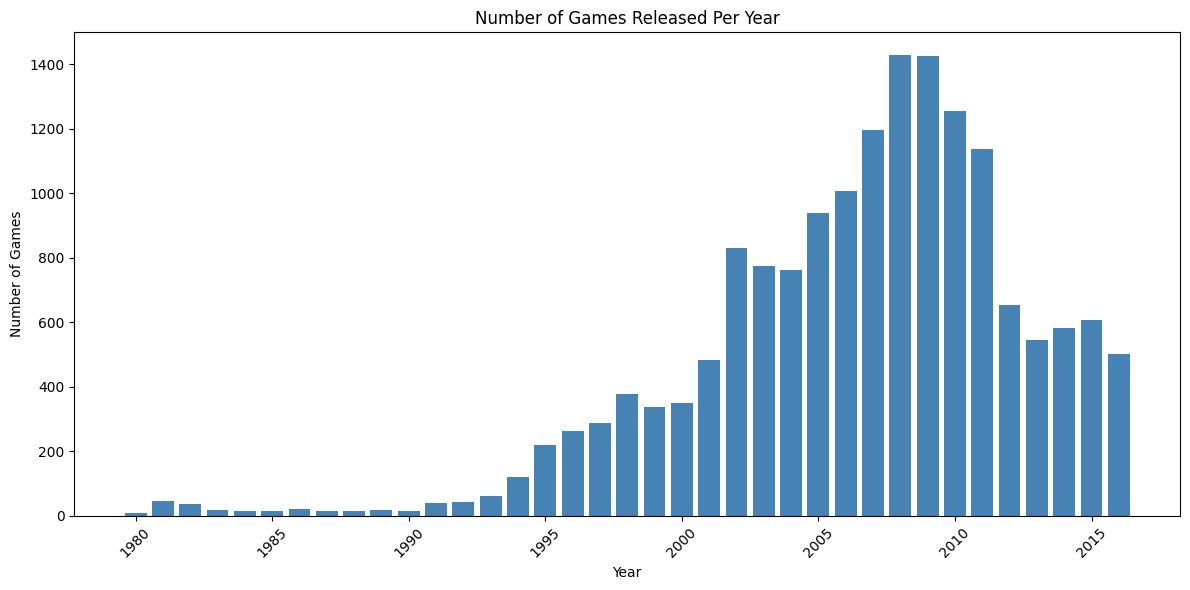

In [16]:
# Visualize the distribution of games across years
plt.figure(figsize=(12, 6))
plt.bar(releases_by_year['year'], releases_by_year['game_count'], color='steelblue')
plt.title('Number of Games Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Display summary statistics for each year
yearly_sales = df.groupby('year_of_release')['total_sales'].agg(['sum', 'mean', 'count'])
yearly_sales.columns = ['total_sales', 'avg_sales', 'game_count']
print(yearly_sales.round(2))

                 total_sales  avg_sales  game_count
year_of_release                                    
1980.0                 11.38       1.26           9
1981.0                 35.68       0.78          46
1982.0                 28.88       0.80          36
1983.0                 16.80       0.99          17
1984.0                 50.35       3.60          14
1985.0                 53.95       3.85          14
1986.0                 37.08       1.77          21
1987.0                 21.70       1.36          16
1988.0                 47.21       3.15          15
1989.0                 73.45       4.32          17
1990.0                 49.37       3.09          16
1991.0                 32.23       0.79          41
1992.0                 76.16       1.77          43
1993.0                 45.99       0.77          60
1994.0                 79.23       0.65         121
1995.0                 88.12       0.40         219
1996.0                199.15       0.76         263
1997.0      

### Questions to Consider:
- Which years show significant numbers of game releases? 1994 nearly doubled compared to 1993 and in 2006-2011 had a significant jump in games.
- Are there any notable trends or patterns in the number of releases? There seems to be a lot of fluctuations in new games released even in newer vs old gen games. 
- Is there enough recent data to make predictions for 2017? 2012-2016 seems to stay in the 500-700.

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [18]:
# Calculate total sales by platform and year
platform_yearly = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
print(platform_yearly.head(20))

    year_of_release platform  total_sales
0            1980.0     2600        11.38
1            1981.0     2600        35.68
2            1982.0     2600        28.88
3            1983.0     2600         5.84
4            1983.0      NES        10.96
5            1984.0     2600         0.27
6            1984.0      NES        50.08
7            1985.0     2600         0.45
8            1985.0       DS         0.02
9            1985.0      NES        53.44
10           1985.0       PC         0.04
11           1986.0     2600         0.67
12           1986.0      NES        36.41
13           1987.0     2600         1.94
14           1987.0      NES        19.76
15           1988.0     2600         0.74
16           1988.0       GB         1.43
17           1988.0      NES        45.01
18           1988.0       PC         0.03
19           1989.0     2600         0.63


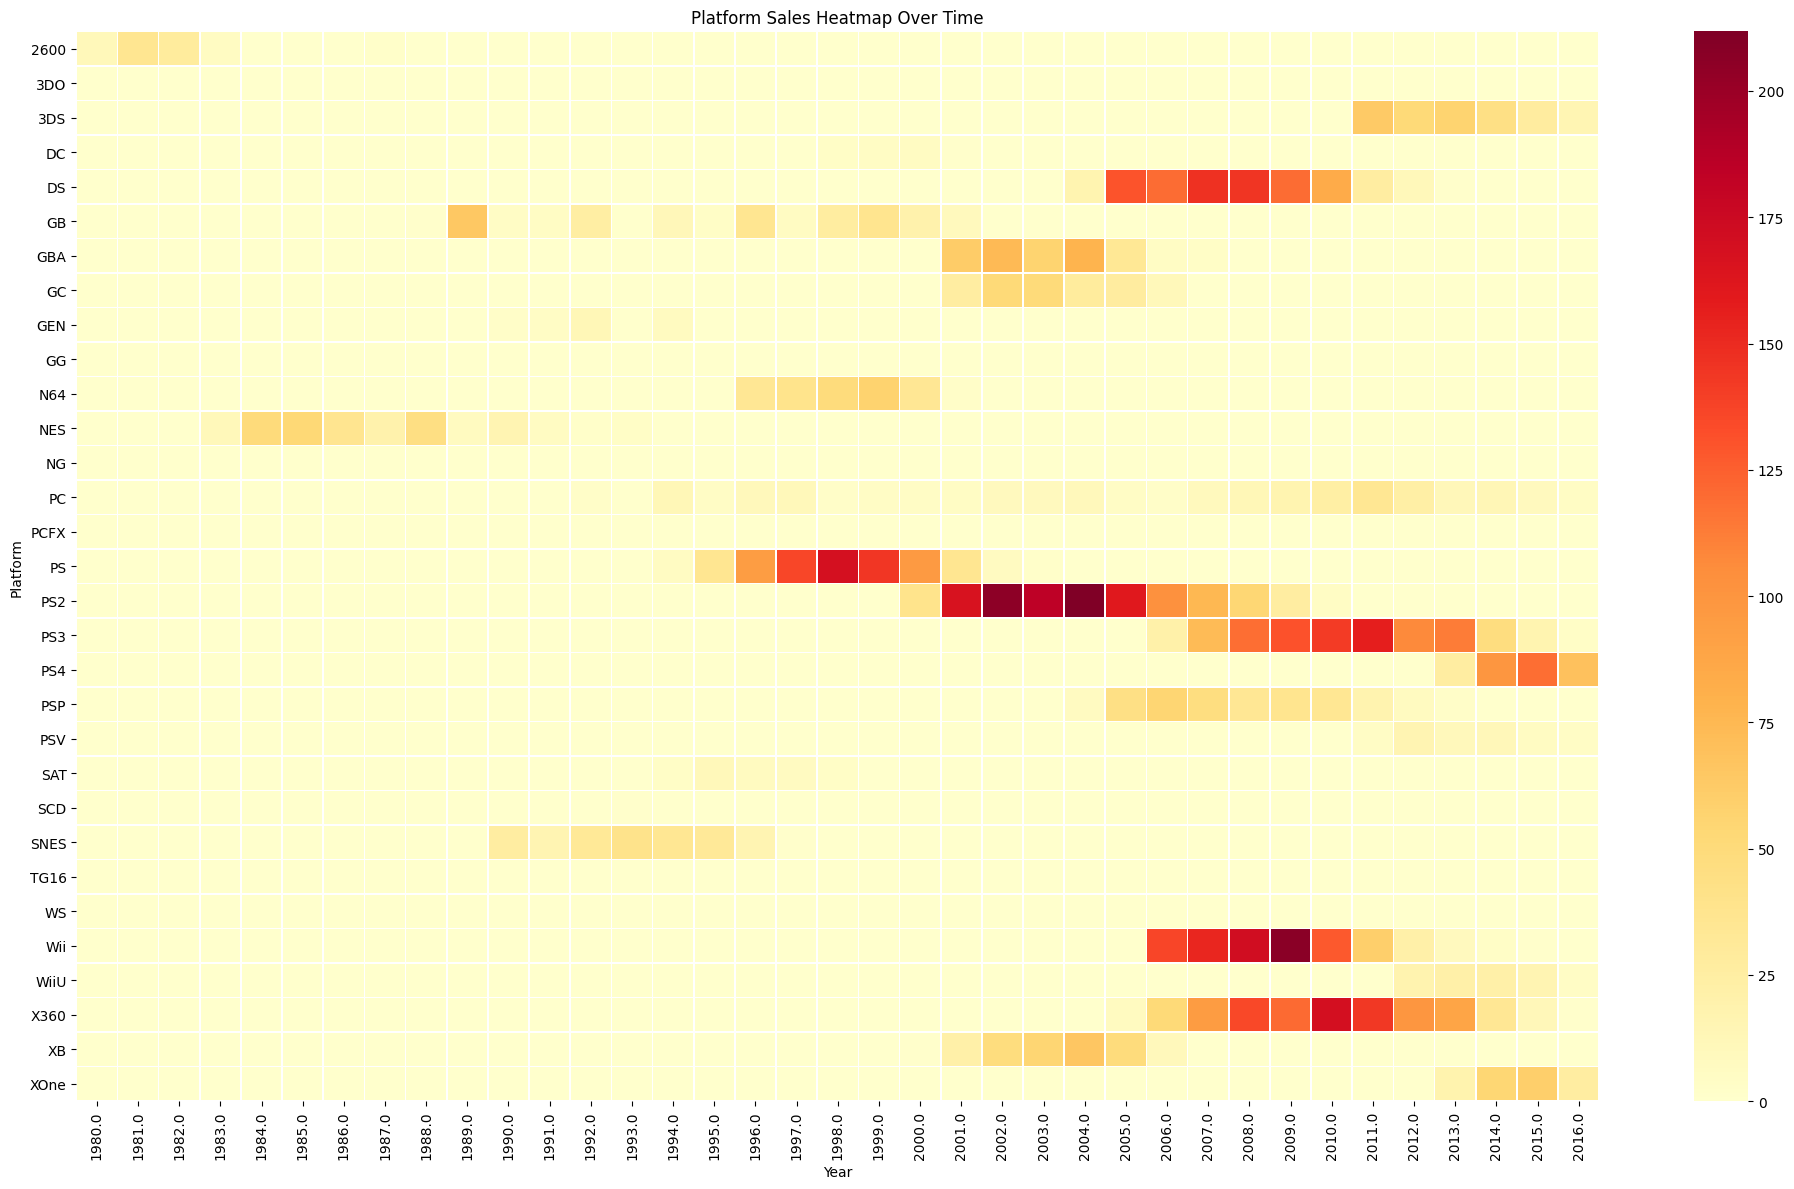

In [19]:
# Create a heatmap of platform sales over time
platform_pivot = platform_yearly.pivot(index='platform', columns='year_of_release', values='total_sales').fillna(0)

plt.figure(figsize=(20, 12))
sns.heatmap(platform_pivot, cmap='YlOrRd', linewidths=0.5)
plt.title('Platform Sales Heatmap Over Time')
plt.xlabel('Year')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()
# First time using heat map this was cool to see!

In [20]:
# Identify platforms with declining sales
last_active = df.groupby('platform')['year_of_release'].max().reset_index()
last_active.columns = ['platform', 'last_active_year']
dead_platforms = last_active[last_active['last_active_year'] < 2014].sort_values('last_active_year')
print("Platforms no longer active after 2013:")
print(dead_platforms)

Platforms no longer active after 2013:
   platform  last_active_year
0      2600            1989.0
9        GG            1992.0
22      SCD            1994.0
8       GEN            1994.0
11      NES            1994.0
1       3DO            1995.0
24     TG16            1995.0
12       NG            1996.0
14     PCFX            1996.0
21      SAT            1999.0
23     SNES            1999.0
25       WS            2001.0
5        GB            2001.0
10      N64            2002.0
15       PS            2003.0
6       GBA            2007.0
7        GC            2007.0
3        DC            2008.0
29       XB            2008.0
16      PS2            2011.0
4        DS            2013.0


## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [21]:
# Your code here to filter the dataset to relevant years
df_relevant = df[df['year_of_release'] >= 2012].copy()
print(f"Relevant dataset shape: {df_relevant.shape}")
print(f"Years covered: {sorted(df_relevant['year_of_release'].unique())}")
# Justify your choice with data

Relevant dataset shape: (2886, 12)
Years covered: [2012.0, 2013.0, 2014.0, 2015.0, 2016.0]


<div class="alert alert-success"><b>Reviewer's comment v2:</b>

Great decision to focus on 2012-2016 data! Your reasoning about platform lifecycles and current market conditions is spot-on. This timeframe captures the current console generation while avoiding the noise from older, discontinued platforms.
</div>

### Document Your Decision:
- What years did you select and why? Data from 2012 onward captures the current generation of platforms
- How does this period reflect current market conditions? Platform lifecycles typically last 5-7 years
- What factors influenced your decision? It is recent enough to forecast 2017

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [22]:
# Analyze platform sales trends
platform_sales = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Total sales by platform (2012-2016):")
print(platform_sales.round(2))

Total sales by platform (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64


In [23]:
# Sort platforms by total sales
top_platforms = platform_sales.head(7).index.tolist()

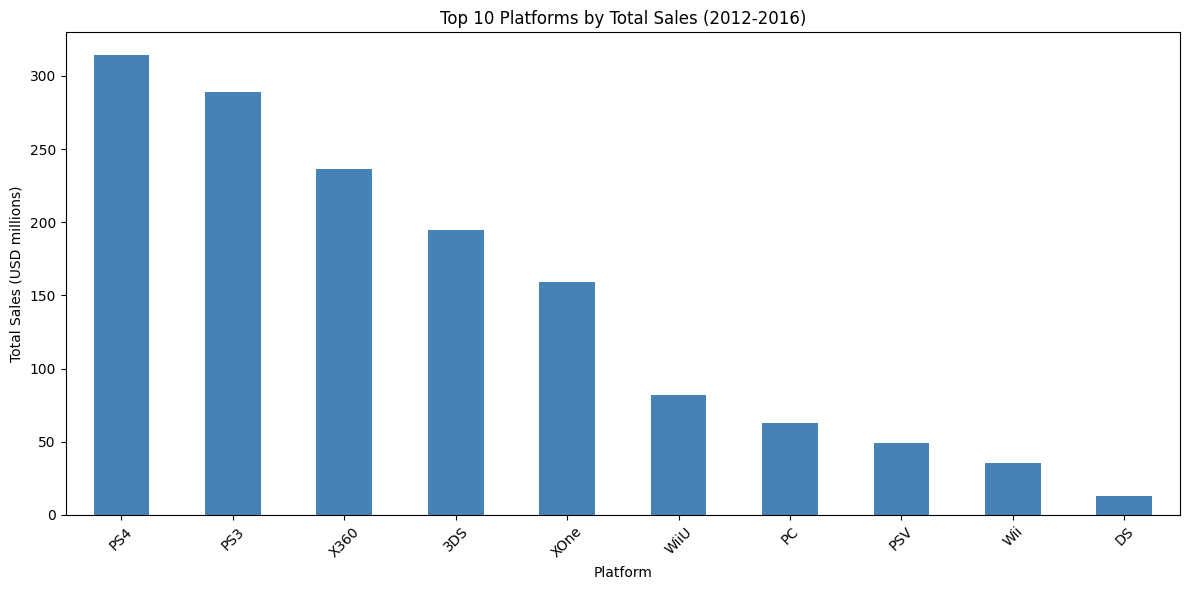

In [24]:
# Visualize top platforms
plt.figure(figsize=(12, 6))
platform_sales.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Platforms by Total Sales (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (USD millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Year-over-Year Growth Rates (%) by Platform:
platform          3DS    PC   PS3    PS4  WiiU  X360   XOne
year_of_release                                            
2012.0            NaN   NaN   NaN    NaN   NaN   NaN    NaN
2013.0           10.1 -46.7   5.5    inf  23.3 -11.2    inf
2014.0          -22.6   7.3 -57.8  284.8   1.8 -60.8  185.2
2015.0          -36.5 -35.8 -64.8   18.9 -25.8 -65.6   11.2
2016.0          -45.5 -38.4 -78.6  -41.8 -71.9 -87.3  -56.5


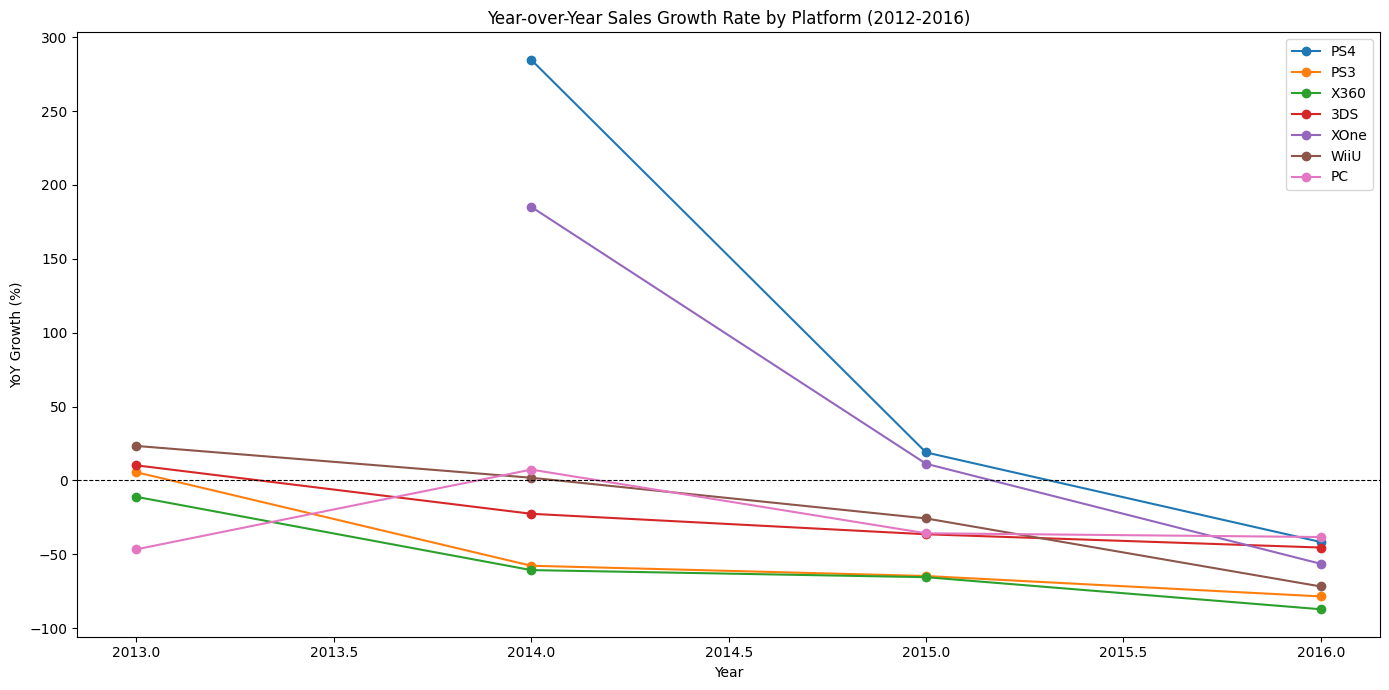

In [25]:
# Calculate year-over-year growth for each platform
platform_yearly_pivot = df_relevant[df_relevant['platform'].isin(top_platforms)]\
    .groupby(['year_of_release', 'platform'])['total_sales']\
    .sum()\
    .unstack(level='platform')\
    .fillna(0)

# Applying pct_change to get YoY growth rates
platform_yoy = platform_yearly_pivot.pct_change() * 100

print("Year-over-Year Growth Rates (%) by Platform:")
print(platform_yoy.round(1))
# Your code here to calculate and visualize platform growth rates

plt.figure(figsize=(14, 7))
for platform in top_platforms:
    if platform in platform_yoy.columns:
        plt.plot(platform_yoy.index, platform_yoy[platform], marker='o', label=platform)

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Year-over-Year Sales Growth Rate by Platform (2012-2016)')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.legend()
plt.tight_layout()
plt.show()

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

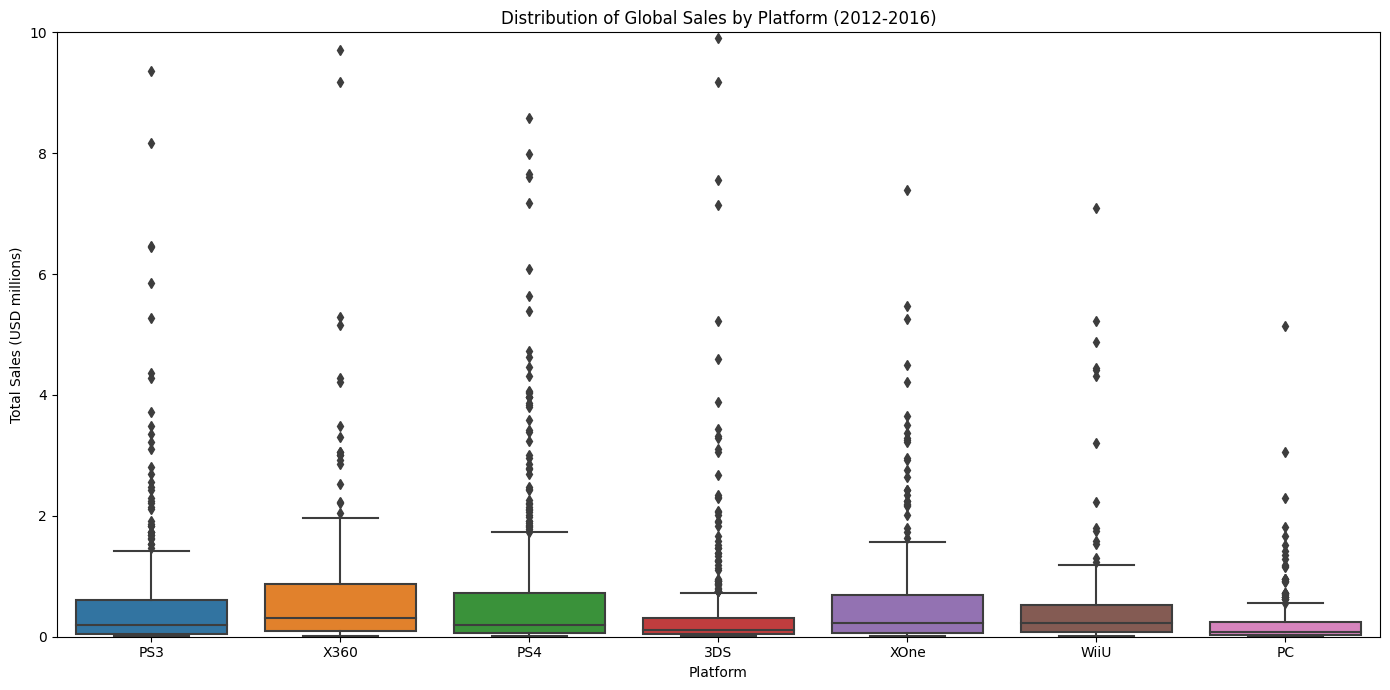

In [26]:
# Create box plot of sales by platform
plt.figure(figsize=(14, 7))
top_platform_data = df_relevant[df_relevant['platform'].isin(top_platforms)]
sns.boxplot(x='platform', y='total_sales', data=top_platform_data)
plt.title('Distribution of Global Sales by Platform (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (USD millions)')
plt.ylim(0, 10)  # Caping y-axis to make box plots readable
plt.tight_layout()
plt.show()

In [27]:
# Calculate detailed statistics for each platform
platform_stats = top_platform_data.groupby('platform')['total_sales'].agg(['mean', 'median', 'std', 'count'])
platform_stats.columns = ['mean_sales', 'median_sales', 'std_dev', 'game_count']
print(platform_stats.sort_values('mean_sales', ascending=False).round(3))

          mean_sales  median_sales  std_dev  game_count
platform                                               
X360           0.810          0.31    1.712         292
PS4            0.801          0.20    1.609         392
XOne           0.645          0.22    1.036         247
PS3            0.586          0.20    1.463         493
WiiU           0.559          0.22    1.059         147
3DS            0.491          0.11    1.387         396
PC             0.251          0.08    0.495         250


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [28]:
# Choose a popular platform based on your previous analysis
platform_choice = 'PS4'
df_platform = df_relevant[df_relevant['platform'] == platform_choice].dropna(subset=['critic_score', 'user_score', 'total_sales'])
print(f"Games on {platform_choice} with full review data: {len(df_platform)}")

Games on PS4 with full review data: 249


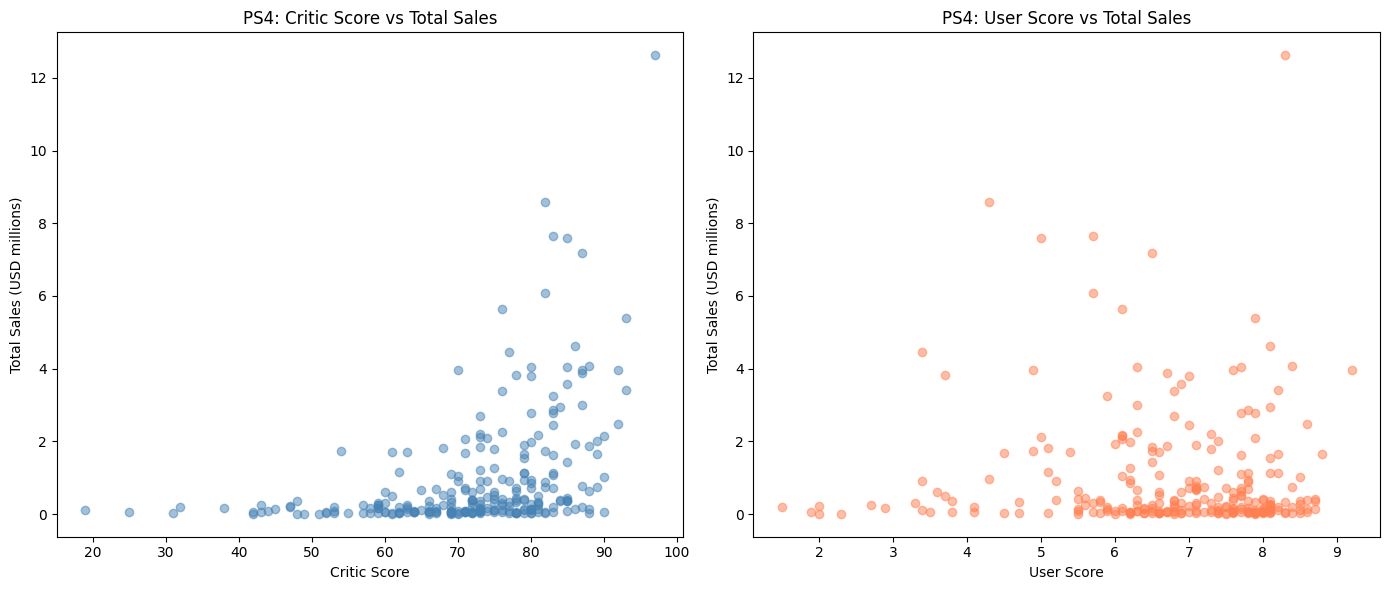

Critic Score correlation with sales: 0.406
User Score correlation with sales: -0.034


In [29]:
# Create scatter plots for both critic and user scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Critic Scores
axes[0].scatter(df_platform['critic_score'], df_platform['total_sales'], alpha=0.5, color='steelblue')
axes[0].set_title(f'{platform_choice}: Critic Score vs Total Sales')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Total Sales (USD millions)')

# User Scores
axes[1].scatter(df_platform['user_score'], df_platform['total_sales'], alpha=0.5, color='coral')
axes[1].set_title(f'{platform_choice}: User Score vs Total Sales')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Total Sales (USD millions)')

plt.tight_layout()
plt.show()

# Calculate correlations
critic_corr = df_platform['critic_score'].corr(df_platform['total_sales'])
user_corr = df_platform['user_score'].corr(df_platform['total_sales'])
print(f"Critic Score correlation with sales: {critic_corr:.3f}")
print(f"User Score correlation with sales: {user_corr:.3f}")

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [30]:
# Find games released on multiple platforms
multi_platform = df_relevant.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform[multi_platform > 1].index.tolist()

In [31]:
# Compare sales across platforms for these games
# Finds games released on multiple platforms
multi_platform = df_relevant.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform[multi_platform > 1].index.tolist()

# Filters to multi-platform games on top platforms only
df_multi = df_relevant[
    (df_relevant['name'].isin(multi_platform_games)) &
    (df_relevant['platform'].isin(top_platforms))
]

pivot_cross = df_multi.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# Keeps only games that appear on at least 2 of the top platforms
pivot_cross = pivot_cross.dropna(thresh=2)

print(f"Multi-platform titles compared: {len(pivot_cross)}")
print(pivot_cross.round(2).head(10))

Multi-platform titles compared: 479
platform                                             3DS    PC   PS3   PS4  \
name                                                                         
2014 FIFA World Cup Brazil                           NaN   NaN  0.61   NaN   
7 Days to Die                                        NaN   NaN   NaN  0.14   
Adventure Time: Explore the Dungeon Because I D...  0.14   NaN  0.04   NaN   
Adventure Time: Finn & Jake Investigations          0.09   NaN  0.08  0.10   
Adventure Time: The Secret of the Nameless          0.01   NaN   NaN   NaN   
Adventure Time: The Secret of the Nameless Kingdom  0.07   NaN   NaN   NaN   
Aegis of Earth: Protonovus Assault                   NaN   NaN  0.02  0.02   
Agatha Christie's The ABC Murders                    NaN   NaN   NaN  0.02   
Akiba's Trip: Undead & Undressed                     NaN   NaN  0.11  0.11   
Alien: Isolation                                     NaN  0.15  0.33  1.12   

platform                   

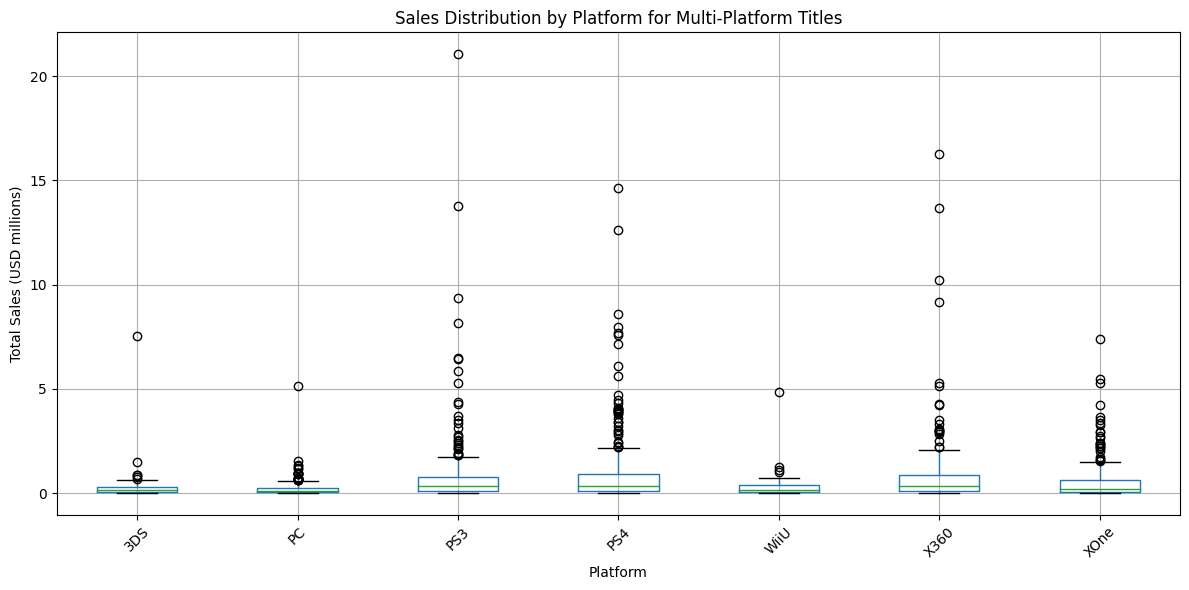

Average sales per platform for shared titles:
platform
PS4     0.953
X360    0.814
PS3     0.767
XOne    0.605
3DS     0.349
WiiU    0.303
PC      0.254
dtype: float64

Number of shared titles per platform:
platform
PS3     327
PS4     291
X360    267
XOne    223
PC      170
WiiU     95
3DS      68
dtype: int64


In [32]:
plt.figure(figsize=(12, 6))
pivot_cross.boxplot(figsize=(12, 6))
plt.title('Sales Distribution by Platform for Multi-Platform Titles')
plt.xlabel('Platform')
plt.ylabel('Total Sales (USD millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average sales per platform across shared titles
avg_by_platform = pivot_cross.mean().sort_values(ascending=False).round(3)
print("Average sales per platform for shared titles:")
print(avg_by_platform)

# Show how many titles each platform has in the comparison
coverage = pivot_cross.count().sort_values(ascending=False)
print("\nNumber of shared titles per platform:")
print(coverage)

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [33]:
# Analyze genre performance
genre_sales = df_relevant.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count'])
genre_sales.columns = ['total_sales', 'avg_sales', 'game_count']

# Sort genres by total sales
genre_sales = genre_sales.sort_values('total_sales', ascending=False)
print(genre_sales.round(3))


              total_sales  avg_sales  game_count
genre                                           
Action             441.12      0.428        1031
Shooter            304.73      1.297         235
Role-Playing       192.80      0.521         370
Sports             181.07      0.676         268
Misc                85.04      0.443         192
Platform            61.00      0.718          85
Racing              53.50      0.465         115
Fighting            44.49      0.408         109
Simulation          35.12      0.439          80
Adventure           29.43      0.097         302
Strategy            13.34      0.188          71
Puzzle               4.89      0.175          28


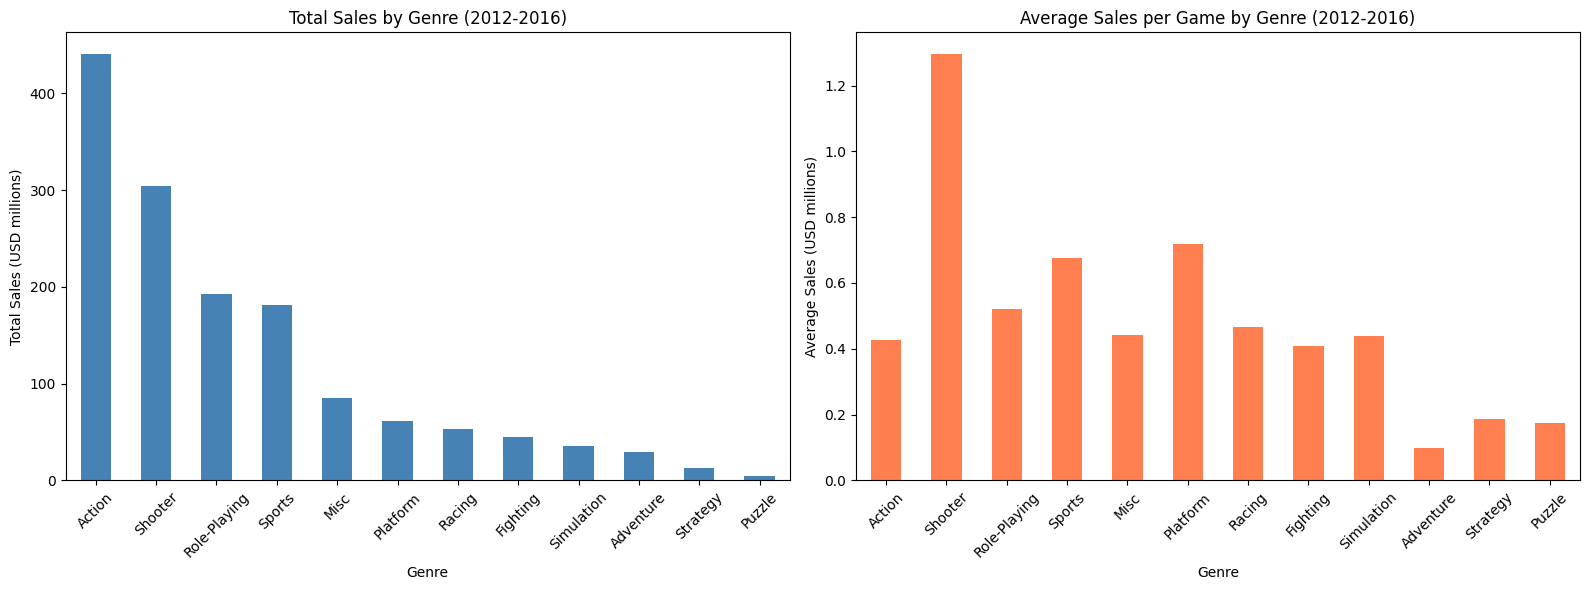

In [34]:
# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total sales by genre
genre_sales['total_sales'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by Genre (2012-2016)')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Total Sales (USD millions)')
axes[0].tick_params(axis='x', rotation=45)

# Average sales by genre
genre_sales['avg_sales'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Sales per Game by Genre (2012-2016)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Average Sales (USD millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Calculate market share for each genre
genre_sales['market_share_%'] = (genre_sales['total_sales'] / genre_sales['total_sales'].sum() * 100).round(2)
print(genre_sales[['total_sales', 'avg_sales', 'game_count', 'market_share_%']])

              total_sales  avg_sales  game_count  market_share_%
genre                                                           
Action             441.12   0.427856        1031           30.50
Shooter            304.73   1.296723         235           21.07
Role-Playing       192.80   0.521081         370           13.33
Sports             181.07   0.675634         268           12.52
Misc                85.04   0.442917         192            5.88
Platform            61.00   0.717647          85            4.22
Racing              53.50   0.465217         115            3.70
Fighting            44.49   0.408165         109            3.08
Simulation          35.12   0.439000          80            2.43
Adventure           29.43   0.097450         302            2.03
Strategy            13.34   0.187887          71            0.92
Puzzle               4.89   0.174643          28            0.34


### Key Questions for Genre Analysis:
- Which genres consistently perform well? Action, Shooter, and Role-Playing perform best, leading in total sales, average sales per game, and market share.
- Are there any genres showing recent growth or decline? From 2012–2016, Puzzle games decline, with decreasing total sales and market share, while top genres remain stable or slightly grow.
- How does the average performance vary across genres? Overall, genres with higher complexity show higher average sales, meaning they perform better per title than simpler genres.

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [36]:
# Function to analyze platform performance by region
def analyze_region_platforms(df, region_col, region_name, top_n=5):
    all_platform_sales = df.groupby('platform')[region_col].sum()
    total_regional_sales = all_platform_sales.sum()
    
    # Gets top N platforms by sales
    top_platforms_region = all_platform_sales.sort_values(ascending=False).head(top_n)
    
    # Market share as % of ALL regional sales
    market_share = (top_platforms_region / total_regional_sales * 100).round(2)
    
    result = pd.DataFrame({
        'total_sales': top_platforms_region.round(2),
        'market_share_%': market_share
    })
    
    print(f"\n--- Top {top_n} Platforms in {region_name} ---")
    print(f"Total regional sales (all platforms): {total_regional_sales:.2f}M")
    print(f"Top {top_n} platforms account for {market_share.sum():.1f}% of regional sales")
    print(result)
    return result

In [37]:
# Analyze each region
na_platforms  = analyze_region_platforms(df_relevant, 'na_sales',    'North America')
eu_platforms  = analyze_region_platforms(df_relevant, 'eu_sales',    'Europe')
jp_platforms  = analyze_region_platforms(df_relevant, 'jp_sales',    'Japan')


--- Top 5 Platforms in North America ---
Total regional sales (all platforms): 590.97M
Top 5 platforms account for 84.7% of regional sales
          total_sales  market_share_%
platform                             
X360           140.05           23.70
PS4            108.74           18.40
PS3            103.38           17.49
XOne            93.12           15.76
3DS             55.31            9.36

--- Top 5 Platforms in Europe ---
Total regional sales (all platforms): 506.82M
Top 5 platforms account for 82.2% of regional sales
          total_sales  market_share_%
platform                             
PS4            141.09           27.84
PS3            106.86           21.08
X360            74.52           14.70
XOne            51.59           10.18
3DS             42.64            8.41

--- Top 5 Platforms in Japan ---
Total regional sales (all platforms): 192.58M
Top 5 platforms account for 89.9% of regional sales
          total_sales  market_share_%
platform                 

### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [38]:
# Create a comparative platform analysis
# Combines top platforms from all regions into one view
all_top_platforms = set(na_platforms.index) | set(eu_platforms.index) | set(jp_platforms.index)

comparison = pd.DataFrame({
    'NA':  df_relevant.groupby('platform')['na_sales'].sum(),
    'EU':  df_relevant.groupby('platform')['eu_sales'].sum(),
    'JP':  df_relevant.groupby('platform')['jp_sales'].sum(),
}).loc[list(all_top_platforms)].fillna(0).round(2)

comparison = comparison.sort_values('NA', ascending=False)
print(comparison)

              NA      EU     JP
platform                       
X360      140.05   74.52   1.57
PS4       108.74  141.09  15.96
PS3       103.38  106.86  35.29
XOne       93.12   51.59   0.34
3DS        55.31   42.64  87.79
WiiU       38.10   25.13  13.01
PSV        10.98   11.36  21.04


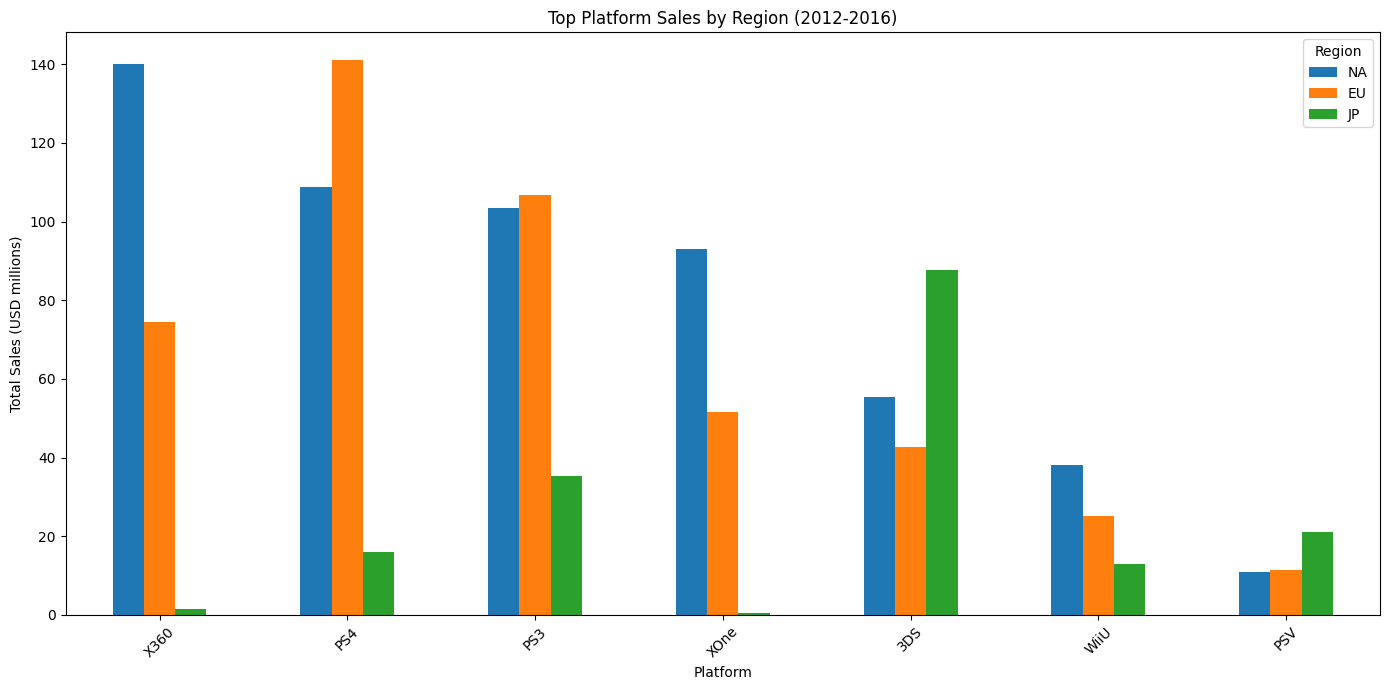

In [39]:
# Visualize cross-regional comparison for top platforms
comparison.plot(kind='bar', figsize=(14, 7))
plt.title('Top Platform Sales by Region (2012-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (USD millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [40]:
# Function to analyze genre performance by region
def analyze_region_genres(df, region_col, region_name, top_n=5):
    all_genre_sales = df.groupby('genre')[region_col].sum()
    total_regional_sales = all_genre_sales.sum()
    
    # Gets top N genres by sales
    top_genres_region = all_genre_sales.sort_values(ascending=False).head(top_n)
    
    market_share = (top_genres_region / total_regional_sales * 100).round(2)
    
    result = pd.DataFrame({
        'total_sales': top_genres_region.round(2),
        'market_share_%': market_share
    })
    
    print(f"\n--- Top {top_n} Genres in {region_name} ---")
    print(f"Total regional sales (all genres): {total_regional_sales:.2f}M")
    print(f"Top {top_n} genres account for {market_share.sum():.1f}% of regional sales")
    print(result)
    return result

**North America:**
Action and Shooter games sell the most in North America, showing people like fast-paced, competitive games. Sports games also do well, mainly because of popular series like Madden and FIFA.

**Europe:**
Europe is very similar to North America, with Action and Shooter games being the most popular. The main difference is that Sports games do a bit better in Europe, likely because soccer is more popular there, which boosts FIFA sales.

**Japan:**
Japan is pretty different from NA and EU. Role-Playing games are the most popular, showing people there like story-driven games. Action games are still around but not as big, and Shooter games are barely popular at all compared to Western markets.

**Key Takeaways:**
- The NA/EU markets are broadly similar in genre preference, making a 
  shared Western strategy viable.
- Japan requires a completely different approach — RPG-focused content on 
  Nintendo platforms rather than shooters on PS4/Xbox One.
- Any genre that ranks highly across all three regions (e.g. Action) 
  represents a globally safe investment for advertising spend.

<div class="alert alert-success"><b>Reviewer's comment v2:</b>

Outstanding regional analysis! Your breakdown of genre preferences by region is insightful and business-relevant. The observation about Japan requiring a completely different approach (RPG-focused on Nintendo platforms vs. shooters on PS4/Xbox) is particularly valuable for strategic planning.
</div>

In [41]:
na_genres = analyze_region_genres(df_relevant, 'na_sales', 'North America')
eu_genres = analyze_region_genres(df_relevant, 'eu_sales', 'Europe')
jp_genres = analyze_region_genres(df_relevant, 'jp_sales', 'Japan')


--- Top 5 Genres in North America ---
Total regional sales (all genres): 590.97M
Top 5 genres account for 85.7% of regional sales
              total_sales  market_share_%
genre                                    
Action             177.84           30.09
Shooter            144.77           24.50
Sports              81.53           13.80
Role-Playing        64.00           10.83
Misc                38.19            6.46

--- Top 5 Genres in Europe ---
Total regional sales (all genres): 506.82M
Top 5 genres account for 82.4% of regional sales
              total_sales  market_share_%
genre                                    
Action             159.34           31.44
Shooter            113.47           22.39
Sports              69.09           13.63
Role-Playing        48.53            9.58
Racing              27.29            5.38

--- Top 5 Genres in Japan ---
Total regional sales (all genres): 192.58M
Top 5 genres account for 78.4% of regional sales
              total_sales  market_

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

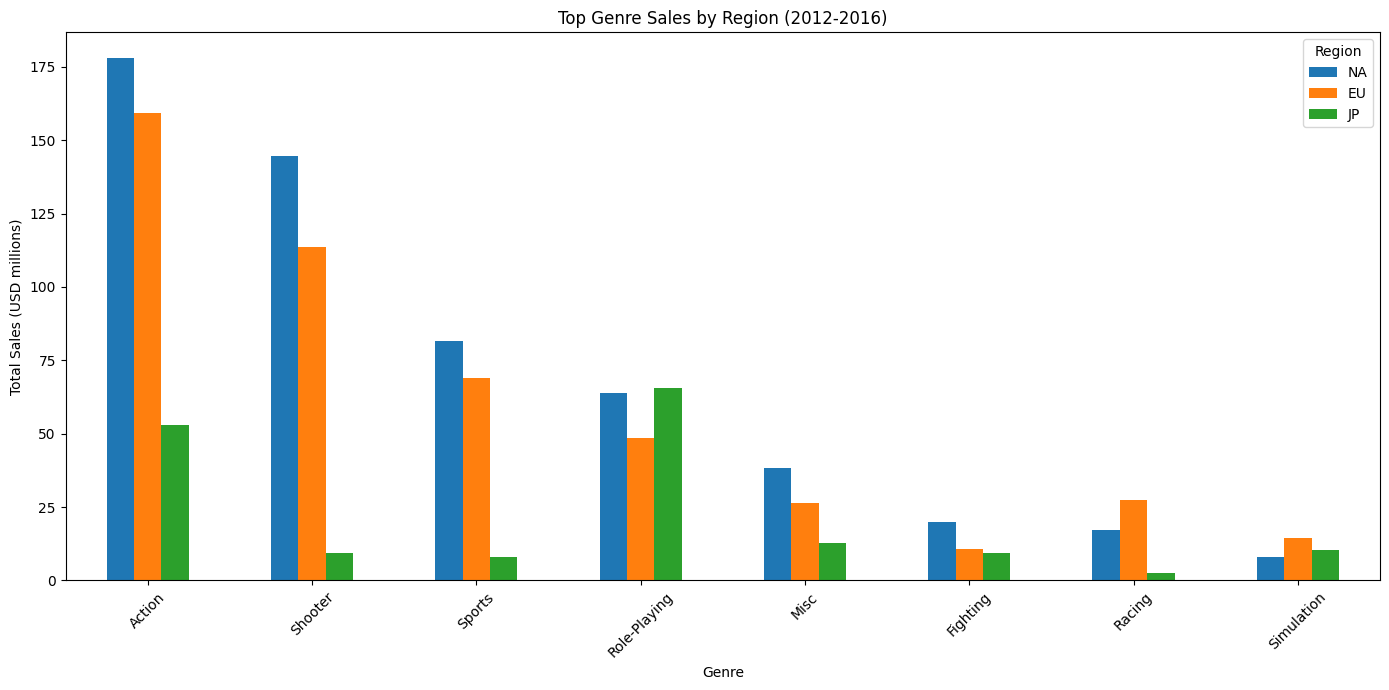

In [42]:
# Create a comparative genre analysis
all_top_genres = set(na_genres.index) | set(eu_genres.index) | set(jp_genres.index)

genre_comparison = pd.DataFrame({
    'NA': df_relevant.groupby('genre')['na_sales'].sum(),
    'EU': df_relevant.groupby('genre')['eu_sales'].sum(),
    'JP': df_relevant.groupby('genre')['jp_sales'].sum(),
}).loc[list(all_top_genres)].fillna(0).round(2)

genre_comparison = genre_comparison.sort_values('NA', ascending=False)

genre_comparison.plot(kind='bar', figsize=(14, 7))
plt.title('Top Genre Sales by Region (2012-2016)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (USD millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [43]:
# Function to analyze ESRB rating impact
def analyze_esrb_impact(df, region_col, region_name):
    esrb_sales = df.groupby('rating')[region_col].agg(['sum', 'mean', 'count'])
    esrb_sales.columns = ['total_sales', 'avg_sales', 'game_count']
    esrb_sales = esrb_sales.sort_values('total_sales', ascending=False).round(2)
    
    print(f"\n--- ESRB Rating Impact in {region_name} ---")
    print(esrb_sales)
    return esrb_sales

In [44]:
na_esrb = analyze_esrb_impact(df_relevant, 'na_sales', 'North America')
eu_esrb = analyze_esrb_impact(df_relevant, 'eu_sales', 'Europe')
jp_esrb = analyze_esrb_impact(df_relevant, 'jp_sales', 'Japan')


--- ESRB Rating Impact in North America ---
        total_sales  avg_sales  game_count
rating                                    
M            231.57       0.46         498
E            114.37       0.29         395
E10+          75.70       0.25         306
T             66.02       0.16         412

--- ESRB Rating Impact in Europe ---
        total_sales  avg_sales  game_count
rating                                    
M            193.96       0.39         498
E            113.03       0.29         395
E10+          55.37       0.18         306
T             52.96       0.13         412

--- ESRB Rating Impact in Japan ---
        total_sales  avg_sales  game_count
rating                                    
E             28.33       0.07         395
T             26.02       0.06         412
M             21.20       0.04         498
E10+           8.19       0.03         306


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You calculated totals/means by ESRB rating, but add a brief written conclusion on whether ratings appear to affect sales in each region, highlighting the key differences between NA/EU vs JP. It’s also worth noting that many games have missing ratings, which can bias the interpretation of the observed pattern.

</div>


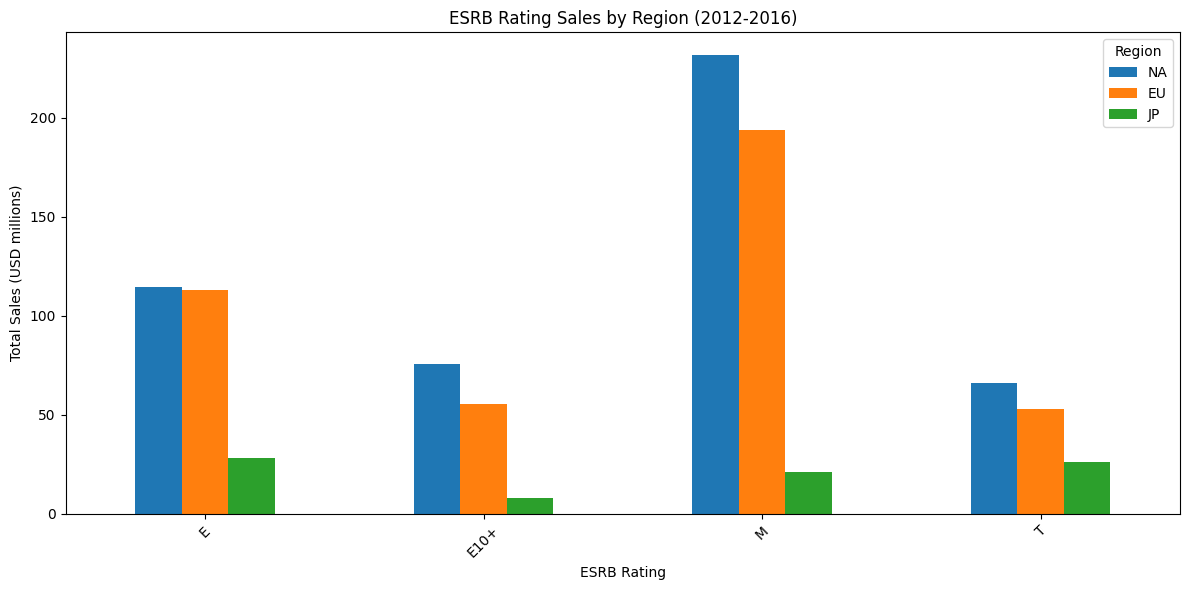

In [45]:
# Analyze ESRB impact for each region
esrb_comparison = pd.DataFrame({
    'NA': df_relevant.groupby('rating')['na_sales'].sum(),
    'EU': df_relevant.groupby('rating')['eu_sales'].sum(),
    'JP': df_relevant.groupby('rating')['jp_sales'].sum(),
}).fillna(0).round(2)

esrb_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('ESRB Rating Sales by Region (2012-2016)')
plt.xlabel('ESRB Rating')
plt.ylabel('Total Sales (USD millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

# Step 5 : Hypothesis Tests


## Hypothesis 1: Average user ratings of Xbox One and PC are the same
- Null hypothesis: The average user ratings for Xbox One and PC are equal
- Alternative hypothesis: The average user ratings for Xbox One and PC are not equal
  
## Hypothesis 2: Average user ratings for Action and Sports genres are different
- Null hypothesis: The average user ratings for Action and Sports are equal
- Alternative hypothesis: The average user ratings for Action and Sports are not equal

I will use an independent samples t-test for both hypotheses because:
- I'm supposed to be comparing means of two independent groups
- The samples are independent of each other
- I set alpha to 0.05 (a 5% significance level), which seemed like a reasonable choice.

## Hypothesis 1

In [46]:
xbox_scores = df_relevant[
    (df_relevant['platform'] == 'XOne') &
    (df_relevant['user_score'].notna())
]['user_score']

pc_scores = df_relevant[
    (df_relevant['platform'] == 'PC') &
    (df_relevant['user_score'].notna())
]['user_score']

print(f"Xbox One samples: {len(xbox_scores)}")
print(f"PC samples: {len(pc_scores)}")
print(f"\nXbox One mean: {xbox_scores.mean():.3f}")
print(f"PC mean: {pc_scores.mean():.3f}")

Xbox One samples: 182
PC samples: 206

Xbox One mean: 6.521
PC mean: 6.429


In [47]:
alpha = 0.05

t_stat, p_value = stats.ttest_ind(xbox_scores, pc_scores)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("The average user ratings for Xbox One and PC are significantly different.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no significant difference between Xbox One and PC user ratings.")

T-statistic: 0.5930
P-value: 0.5535

Result: Fail to reject the null hypothesis.
There is no significant difference between Xbox One and PC user ratings.


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work: you clearly stated H0/H1, used an appropriate independent two-sample t-test, set an alpha level, and interpreted the p-value correctly for the Xbox One vs. PC comparison.

</div>


## Hypothesis 2

In [48]:
action_scores = df_relevant[
    (df_relevant['genre'] == 'Action') &
    (df_relevant['user_score'].notna())
]['user_score']

sports_scores = df_relevant[
    (df_relevant['genre'] == 'Sports') &
    (df_relevant['user_score'].notna())
]['user_score']

print(f"Action samples: {len(action_scores)}")
print(f"Sports samples: {len(sports_scores)}")
print(f"\nAction mean: {action_scores.mean():.3f}")
print(f"Sports mean: {sports_scores.mean():.3f}")

Action samples: 523
Sports samples: 195

Action mean: 6.825
Sports mean: 5.456


In [49]:
t_stat2, p_value2 = stats.ttest_ind(action_scores, sports_scores)

print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
print()
if p_value2 < alpha:
    print("Result: Reject the null hypothesis.")
    print("The average user ratings for Action and Sports genres are significantly different.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no significant difference between Action and Sports user ratings.")

T-statistic: 11.0106
P-value: 0.0000

Result: Reject the null hypothesis.
The average user ratings for Action and Sports genres are significantly different.


# Step 6. Write a general conclusion


## Data Preparation
Before I began the analysis, I had to spend some time cleaning and preparing the dataset. I standardized the column names by converting them to lowercase and made sure important fields like user_score and year_of_release were in the correct numeric format. I also handled entries like “tbd” in the user_score column by converting them to missing values. Any rows missing key information like game names or release years were removed since they wouldn’t be useful for time-based analysis. For other missing values, like review scores and ESRB ratings, I chose to leave them as NaN because there wasn’t a reliable way to fill them in.

## Temporal Analysis
When I looked at trends over time, I noticed that game releases peaked around 2008–2009 and have generally declined since then. Because of this, I decided to focus on data from 2012 onward for forecasting, since earlier data reflects older console generations that aren’t as relevant. This also aligns with the typical 5–7 year lifecycle of gaming platforms, meaning the platforms active between 2012 and 2016 are the most useful for predicting 2017 trends.

## Platform Analysis
From the platform analysis, it became clear that the PS4 and Xbox One were the dominant systems during this period, with the PS4 showing the strongest sales growth overall. At the same time, older platforms like the PS3 and Xbox 360 were clearly declining as the industry transitioned to newer hardware. The 3DS still held its ground, especially in Japan. I also found that while a small number of games generate very high sales, most games perform modestly, which suggests that a few blockbuster titles drive the majority of revenue.

## Review Score Impact
Looking at review scores, I found that critic scores had a moderate positive relationship with sales on the PS4, meaning higher-rated games tended to sell better. User scores, on the other hand, showed a much weaker relationship. This suggests that professional reviews may have more influence on purchasing decisions than user ratings.

## Regional Analysis
There were also clear differences between regions. In North America and Europe, the PS4 and Xbox One were the most popular platforms, and Action and Shooter games dominated sales. In contrast, Japan showed a strong preference for Nintendo platforms, especially the 3DS, with Role-Playing games being by far the most popular genre. ESRB ratings also seemed to matter more in North America and Europe, where Mature-rated games performed well, while they had less impact in Japan.

## Hypothesis Testing
For the hypothesis testing, I found that there was no statistically significant difference in average user ratings between Xbox One and PC games at the 0.05 significance level, so I failed to reject the null hypothesis. However, I did find a significant difference in user ratings between Action and Sports games, which led me to reject the second null hypothesis.

## Recommendations for 2017
Based on all of this, I would recommend focusing the 2017 advertising strategy on PS4 and Xbox One, since they are the leading and still-growing platforms. In North America and Europe, it would make sense to prioritize Action, Shooter, and Sports games, while in Japan, the focus should be on Role-Playing games for Nintendo platforms. I would also prioritize promoting games with strong critic scores, since they tend to perform better in sales. Finally, emphasizing Mature-rated games in North America and Europe would likely be effective, given their strong performance in those regions.


<div class="alert alert-success"><b>Reviewer's comment v2:</b>

Excellent comprehensive conclusion! You've effectively synthesized all your analytical findings into actionable business recommendations. The structure flows logically from data preparation through analysis to specific recommendations for 2017. Your insights about regional differences and platform strategies are particularly valuable for Ice's advertising planning.
</div>